# Flood and Drought Risk Analysis Perception (RAP) Framework for India

## **Contributors**
- **Team Lead:** Jennifer Marlon, Ph.D.  
- **Team Members:** Deepika Pingali, Surabhi Upadhyay, Emine Senkardesler, Pratyush Tripathy, Okikiola Michael Alegbeleye  

**Developed for:** *I-GUIDE Summer School on "Spatial AI for Extreme Events and Disaster Resilience"*  
**Date:** August 4–8, 2025  

## **Data and Model Cards**
- [I-GUIDE Data Card DC01 – ERA5 Climate Data](https://github.com/surabhiupadhyay/RAP_India/raw/main/Model-and-Data-Cards/I-GUIDE%20Data%20Card_DC01.docx)
- [I-GUIDE Data Card DC02 – Alpha Earth Embeddings](https://github.com/surabhiupadhyay/RAP_India/raw/main/Model-and-Data-Cards/I-GUIDE%20Data%20Card_DC02.docx)
- [I-GUIDE Data Card DC03 – VIIRS Nighttime Data](https://github.com/surabhiupadhyay/RAP_India/raw/main/Model-and-Data-Cards/I-GUIDE%20Data%20Card_DC03.docx)
- [I-GUIDE Model Card MC01 – RAP Framework Model](https://github.com/surabhiupadhyay/RAP_India/raw/main/Model-and-Data-Cards/I-GUIDE%20Model%20Card_MC01.docx)

---

## **Variables**

### **Dependent Variable**
- **Survey-Based Drought Vulnerability Outcome**  
  *Examples:* Perceived flood risk, perceived drought risk  

### **Covariates / Independent Variables**

#### **Individual-Level**
- Age  
- Gender  
- Education  
- Caste  

#### **District-Level**
- **News Media Webscraping for Floods**  
- **VIIRS Nighttime Radiance**  
- **Alpha Earth Embeddings**  
- **ERA5 Climate Data:**  
  - Monthly Precipitation  
  - Monthly Temperature  

---

## **Modeling Scenarios**

### **Model 1: Baseline**
- Uses only individual-level demographic variables:  
  *Age, Gender, Education, Caste*

### **Model 2: Demographics + Physical Features**
- Includes **Model 1 variables** + **District-level physical features**:  
  *VIIRS Radiance, ERA5 Precipitation & Temperature, News Mentions*

### **Model 3: Demographics + Alpha Earth Embeddings**
- Includes **Model 1 variables** + **Alpha Earth Embeddings**

### **Model 4: Full Integrated Model**
- Combines **all covariates**:  
  *Demographics + District-level physical features + Alpha Earth Embeddings*

---

## **Machine Learning Methods**
- **Random Forest** 
- **XGBoost**
- **Logistic Regression**

In [90]:
%%time

# import required libraries
import requests
from tqdm import tqdm
import pandas as pd

# File URL
url = "https://zenodo.org/records/16781519/files/RAR_TEAM1_FinalCleanedData_250807.csv?download=1"
output_file = "RAR_TEAM1_FinalCleanedData_250807.csv"

# Stream download with progress bar
response = requests.get(url, stream=True)
total_size = int(response.headers.get('content-length', 0))
block_size = 1024  # 1 KB

with open(output_file, 'wb') as file, tqdm(
    desc="Downloading CSV",
    total=total_size,
    unit='B',
    unit_scale=True,
    unit_divisor=1024
) as bar:
    for data in response.iter_content(block_size):
        file.write(data)
        bar.update(len(data))

# Load into pandas
try:
    df = pd.read_csv(output_file)
    print(f"File downloaded and loaded successfully!\nSaved at: {output_file}")
except Exception as e:
    print(f"Could not load the file: {e}")


File downloaded and loaded successfully!
Saved at: RAR_TEAM1_FinalCleanedData_250807.csv
CPU times: total: 3.7 s
Wall time: 52.7 s


In [2]:
%%time

import pandas as pd
import numpy as np

# read the data
data_df = pd.read_csv('RAR_TEAM1_FinalCleanedData_250807.csv')
data_df['di_code'] = data_df['di_code'].astype(int)

# add flow accumulation and historical flood information
flow_df = pd.read_csv(r'../../datafiles/external/FlowAccumulation/India_FlowAccumulation.csv')
flow_df['FlowAcc_sum'] = 100 * flow_df['FlowAcc_sum'] / flow_df['Shape_Area']
flow_df = flow_df[['di_code', 'FlowAcc_sum']]
flow_df['di_code'] = data_df['di_code'].astype(int)

flood_history_df = pd.read_csv(r'../../datafiles/external/FloodHistory/India_HistoricalFloods.csv')
flood_history_df['GFD_sum'] = 250 * 250 * flood_history_df['GFD_sum'] / flood_history_df['Shape_Area']
flood_history_df = flood_history_df[['di_code', 'GFD_sum']]
flood_history_df = flood_history_df.fillna(-9999)
flood_history_df['di_code'] = flood_history_df['di_code'].astype(int)

data_df = data_df.merge(flow_df, on='di_code', how='left').merge(flood_history_df, on='di_code', how='left')
data_df = data_df.fillna(0)

print(data_df.shape)
data_df.head()

(35543, 610)
CPU times: total: 1.16 s
Wall time: 1.17 s


,Unnamed: 0.1,caseid,weight,wave,state,district,urban,gender,age,caste,...,A63_p95,A63_p98,A63_sum,A63_mean,A63_min,A63_max,A63_count,split,FlowAcc_sum,GFD_sum
0,0,10001,0.840547,2024,NE,East Khasi Hills,Urban,Male,18-29,Scheduled Castes/Tribes,...,0.124567,0.147697,43582.604336,0.012406,-0.267958,0.327812,3519450,train,0.004987,0.015964
1,1,10002,1.360886,2024,UT,Leh,Rural,Female,45+,Scheduled Castes/Tribes,...,0.141730,0.267958,-117536.992772,-0.024344,-0.318893,0.346021,4837249,train,0.005490,0.005903
2,1,10002,1.360886,2024,UT,Leh,Rural,Female,45+,Scheduled Castes/Tribes,...,0.141730,0.267958,-117536.992772,-0.024344,-0.318893,0.346021,4837249,train,0.004280,0.005903
3,1,10002,1.360886,2024,UT,Leh,Rural,Female,45+,Scheduled Castes/Tribes,...,0.141730,0.267958,-117536.992772,-0.024344,-0.318893,0.346021,4837249,train,4.442896,0.005903
4,1,10002,1.360886,2024,UT,Leh,Rural,Female,45+,Scheduled Castes/Tribes,...,0.141730,0.267958,-117536.992772,-0.024344,-0.318893,0.346021,4837249,train,3.655635,0.005903


## Define column names for different models

In [3]:
# create keys for all four models
features_list_model1 = ['age', 'gender', 'urban', 'caste', 'di_code']
features_list_model2 = features_list_model1 + ['mean_monthly_avg_rd_MD', 'precip_sum_mm', 'precip_mean_mm', 'mean_tmax', 'district_flood_sentiment', 'state_flood_sentiment']
features_list_model3 = features_list_model2 + ['FlowAcc_sum', 'GFD_sum']
features_list_model4 = features_list_model1 + [
    f'{var}_{metric}'
    for var in sorted(set([
        data.split('_')[0] 
        for data in data_df.loc[:, data_df.columns.str.startswith('A')].keys()
    ]))
    for metric in ['min', 'p2', 'mean', 'p98', 'max', 'sum', 'count']
]
features_list_model5 = list(set(features_list_model2 + features_list_model4))

flood_y_key = 'n7fy23_recode'
drought_y_key = 'n7dy23_recode'

## Prepare data for the model

In [4]:
%%time

from sklearn.preprocessing import LabelEncoder

# Encode categorical variables FIRST (on full dataset)
data_encoded = data_df.copy()
encoders = {}

for var in ['age', 'gender', 'urban', 'caste', 'di_code']:
    encoders[var] = LabelEncoder()
    data_encoded[var] = encoders[var].fit_transform(data_df[var])

# Split the encoded data (general variables)
X_train_encoded = data_encoded[data_encoded['split'] == 'train']
X_test_encoded = data_encoded[data_encoded['split'] == 'test']
y_train = data_encoded[data_encoded['split'] == 'train'][flood_y_key]
y_test = data_encoded[data_encoded['split'] == 'test'][flood_y_key]

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")
print(f"y_test shape: {y_test.shape}")

X_train_encoded shape: (30663, 610)
y_train shape: (30663,)
X_test_encoded shape: (4880, 610)
y_test shape: (4880,)
CPU times: total: 516 ms
Wall time: 6.96 s


In [5]:
import time
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

def train_models_with_features(X_train_encoded, X_test_encoded, y_train, y_test, 
                               features_list, model_name_suffix=""):
    """
    Train multiple models with specified features and save results
    
    Parameters:
    -----------
    X_train_encoded : DataFrame
        Training features (encoded)
    X_test_encoded : DataFrame  
        Test features (encoded)
    y_train : array-like
        Training target
    y_test : array-like
        Test target
    features_list : list
        List of feature names to use
    model_name_suffix : str
        Suffix to add to saved model files (e.g., "model1", "model2")
    
    Returns:
    --------
    tuple: (metrics_df, trained_models, feature_importance_results)
    """
    
    print(f"{'='*60}")
    print(f"Training models with {len(features_list)} features")
    if model_name_suffix:
        print(f"Model suffix: {model_name_suffix}")
    print(f"{'='*60}")
    
    # Extract features
    X_train_subset = X_train_encoded[features_list]
    X_test_subset = X_test_encoded[features_list]
    
    # Define models and parameters
    models = {
        'RF': (RandomForestClassifier(random_state=42), {
            'n_estimators': [5], 'max_depth': [5]}),
        
        #'GradientBoosting': (GradientBoostingClassifier(random_state=42), {
        #    'n_estimators': [100, 200], 'learning_rate': [0.1, 0.2], 'max_depth': [3, 5]}),
        
        'LR': (LogisticRegression(random_state=42, max_iter=1000), {
            'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']})
    }
    
    results = []
    trained_models = {}
    feature_importance_results = {}
    
    # Train each model
    for name, (model, params) in models.items():
        print(f"Training {name}...")
        start = time.time()
        
        grid = GridSearchCV(model, params, cv=5, scoring='accuracy')
        grid.fit(X_train_subset, y_train)
        
        # Store the best estimator
        trained_models[name] = grid.best_estimator_
        
        # Make predictions
        train_pred = grid.predict(X_train_subset)
        test_pred = grid.predict(X_test_subset)
        train_proba = grid.predict_proba(X_train_subset)[:, 1]
        test_proba = grid.predict_proba(X_test_subset)[:, 1]
        
        # Calculate metrics
        results.append({
            'Model': f'{model_name_suffix}_{name}',
            'Train_Accuracy': accuracy_score(y_train, train_pred),
            'Test_Accuracy': accuracy_score(y_test, test_pred),
            'Train_Precision': precision_score(y_train, train_pred),
            'Test_Precision': precision_score(y_test, test_pred),
            'Train_Recall': recall_score(y_train, train_pred),
            'Test_Recall': recall_score(y_test, test_pred),
            'Train_F1': f1_score(y_train, train_pred),
            'Test_F1': f1_score(y_test, test_pred),
            'Train_AUC': roc_auc_score(y_train, train_proba),
            'Test_AUC': roc_auc_score(y_test, test_proba)
        })
        
        print(f"{name} - Test Acc: {results[-1]['Test_Accuracy']:.3f}, Test AUC: {results[-1]['Test_AUC']:.3f}")
        print(f"Time: {time.time()-start:.1f}s\n")
    
    # Create metrics DataFrame
    metrics_df = pd.DataFrame(results)
    
    # Print results nicely
    print("FINAL RESULTS:")
    display_df = metrics_df.round(3).set_index('Model').T
    print(display_df)
    print()
    
    # Extract feature importance
    print("Extracting feature importance...")
    for model_name, trained_model in trained_models.items():
        importance_df = get_feature_importance(trained_model, model_name, features_list)
        if importance_df is not None:
            feature_importance_results[model_name] = importance_df
            print(f"{model_name} - Top 5 features:")
            print(importance_df.head(5)[['Feature', 'Importance']].to_string(index=False))
            print()
    
    # Save everything
    save_results(metrics_df, trained_models, feature_importance_results, 
                 features_list, model_name_suffix)
    
    return metrics_df, trained_models, feature_importance_results

def get_feature_importance(model, model_name, feature_names):
    """Extract feature importance based on model type"""
    
    if hasattr(model, 'feature_importances_'):
        # Tree-based models
        importance = model.feature_importances_
        importance_type = 'Gini/Entropy Importance'
        
    elif hasattr(model, 'coef_'):
        # Linear models
        importance = np.abs(model.coef_[0])
        importance_type = 'Coefficient Magnitude'
        
    else:
        print(f"Feature importance not available for {model_name}")
        return None
    
    # Create feature importance DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance,
        'Model': model_name,
        'Importance_Type': importance_type
    }).sort_values('Importance', ascending=False)
    
    return feature_importance_df

def save_results(metrics_df, trained_models, feature_importance_results, 
                 features_list, model_name_suffix):
    """Save all results to files"""
    
    # Create directory
    save_dir = 'saved_models'
    os.makedirs(save_dir, exist_ok=True)
    
    # Create file suffix
    suffix = f"_{model_name_suffix}" if model_name_suffix else ""
    
    # Save models
    for model_name, trained_model in trained_models.items():
        joblib.dump(trained_model, f'{save_dir}/{model_name}_model{suffix}.pkl')
    
    # Save feature importance
    for model_name, importance_df in feature_importance_results.items():
        importance_df.to_csv(f'{save_dir}/{model_name}_feature_importance{suffix}.csv', index=False)
    
    # Save metrics and features
    metrics_df.to_csv(f'{save_dir}/model_metrics{suffix}.csv', index=False)
    joblib.dump(features_list, f'{save_dir}/feature_list{suffix}.pkl')
    
    print(f"Results saved with suffix '{suffix}' in '{save_dir}/' directory")

In [6]:
%%time


# Train with first set of features
metrics1, models1, importance1 = train_models_with_features(
    X_train_encoded[features_list_model1], X_test_encoded[features_list_model1], y_train, y_test, 
    features_list_model1, "M1"
)

# Train with second set of features  
metrics2, models2, importance2 = train_models_with_features(
    X_train_encoded[features_list_model2], X_test_encoded[features_list_model2], y_train, y_test,
    features_list_model2, "M2"
)

# Train with third set of features
metrics3, models3, importance3 = train_models_with_features(
    X_train_encoded[features_list_model3], X_test_encoded[features_list_model3], y_train, y_test,
    features_list_model3, "M3"
)

# Train with fourth set of features
metrics4, models4, importance4 = train_models_with_features(
    X_train_encoded[features_list_model4], X_test_encoded[features_list_model4], y_train, y_test,
    features_list_model4, "M4"
)

# Train with fifth set of features
metrics5, models5, importance5 = train_models_with_features(
    X_train_encoded[features_list_model5], X_test_encoded[features_list_model5], y_train, y_test,
    features_list_model5, "M5"
)

Training models with 5 features
Model suffix: M1
Training RF...
RF - Test Acc: 0.581, Test AUC: 0.600
Time: 0.2s

Training LR...
LR - Test Acc: 0.581, Test AUC: 0.599
Time: 0.6s

FINAL RESULTS:
Model            M1_RF  M1_LR
Train_Accuracy   0.587  0.558
Test_Accuracy    0.581  0.581
Train_Precision  0.564  0.546
Test_Precision   0.593  0.605
Train_Recall     0.582  0.420
Test_Recall      0.682  0.615
Train_F1         0.573  0.475
Test_F1          0.635  0.610
Train_AUC        0.620  0.567
Test_AUC         0.600  0.599

Extracting feature importance...
RF - Top 5 features:
Feature  Importance
di_code    0.523382
  urban    0.236094
    age    0.112030
 gender    0.064280
  caste    0.064214

LR - Top 5 features:
Feature  Importance
  urban    0.356245
  caste    0.154763
 gender    0.059811
    age    0.021672
di_code    0.001026

Results saved with suffix '_M1' in 'saved_models/' directory
Training models with 11 features
Model suffix: M2
Training RF...
RF - Test Acc: 0.587, Test AUC: 

In [7]:
# metrics with RF trees and depth set to 5
pd.concat([
    metrics1, metrics2, metrics3, metrics4, metrics5
], axis=0)

,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_AUC,Test_AUC
0,M1_RF,0.587125,0.581352,0.564324,0.593447,0.581569,0.682168,0.572817,0.634722,0.619864,0.599752
1,M1_LR,0.557512,0.580533,0.545722,0.604994,0.419938,0.614527,0.474638,0.609724,0.567209,0.599457
0,M2_RF,0.585396,0.587090,0.579009,0.596897,0.472491,0.694850,0.520355,0.642159,0.618291,0.604266
1,M2_LR,0.559926,0.583607,0.545955,0.600141,0.448099,0.656418,0.492210,0.627019,0.570246,0.607300
0,M3_RF,0.589701,0.568648,0.591197,0.574917,0.447276,0.732898,0.509264,0.644366,0.630522,0.589016
1,M3_LR,0.558328,0.575000,0.545573,0.593750,0.431449,0.642583,0.481846,0.617202,0.570903,0.599874
0,M4_RF,0.577504,0.562090,0.587012,0.576860,0.379034,0.670638,0.460635,0.620224,0.605708,0.565381
1,M4_LR,0.566318,0.510656,0.565196,0.538740,0.385200,0.571868,0.458153,0.554810,0.582584,0.544213
0,M5_RF,0.581059,0.528074,0.581296,0.551534,0.428434,0.614912,0.493294,0.581501,0.611220,0.549617
1,M5_LR,0.566285,0.510656,0.565428,0.538740,0.383693,0.571868,0.457162,0.554810,0.582708,0.547433


In [71]:
# metrics with RF trees and depth set to 25
pd.concat([
    metrics1, metrics2, metrics5
], axis=0)

,Model,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_AUC,Test_AUC
0,model1_RandomForest,0.587125,0.581352,0.564324,0.593447,0.581569,0.682168,0.572817,0.634722,0.619864,0.599752
1,model1_LogisticRegression,0.557512,0.580533,0.545722,0.604994,0.419938,0.614527,0.474638,0.609724,0.567209,0.599457
0,model2_RandomForest,0.585396,0.587090,0.579009,0.596897,0.472491,0.694850,0.520355,0.642159,0.618291,0.604266
1,model2_LogisticRegression,0.559926,0.583607,0.545955,0.600141,0.448099,0.656418,0.492210,0.627019,0.570246,0.607300
0,model5_RandomForest,0.589701,0.568648,0.591197,0.574917,0.447276,0.732898,0.509264,0.644366,0.630522,0.589016
1,model5_LogisticRegression,0.558328,0.575000,0.545573,0.593750,0.431449,0.642583,0.481846,0.617202,0.570903,0.599874


## Make the plots

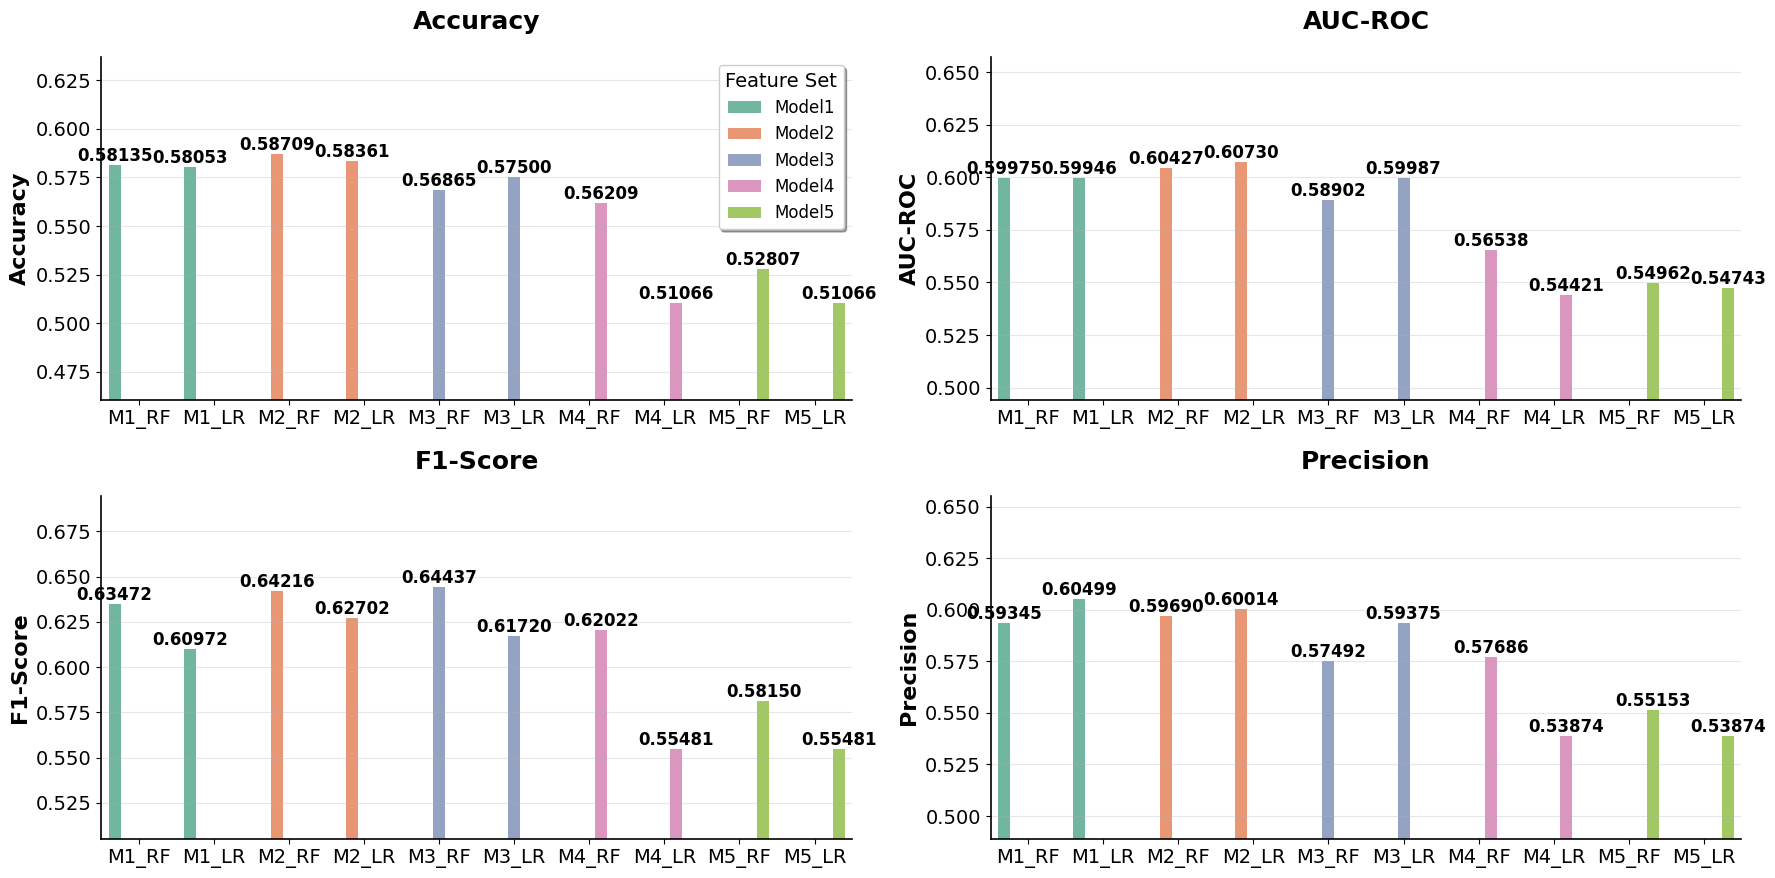


PERFORMANCE SUMMARY TABLE

M1_RF:
Feature_Set  Test_Accuracy  Test_AUC  Test_F1  Test_Precision
     Model1           0.58       0.6     0.63            0.59

M1_LR:
Feature_Set  Test_Accuracy  Test_AUC  Test_F1  Test_Precision
     Model1           0.58       0.6     0.61             0.6

M2_RF:
Feature_Set  Test_Accuracy  Test_AUC  Test_F1  Test_Precision
     Model2           0.59       0.6     0.64             0.6

M2_LR:
Feature_Set  Test_Accuracy  Test_AUC  Test_F1  Test_Precision
     Model2           0.58      0.61     0.63             0.6

M3_RF:
Feature_Set  Test_Accuracy  Test_AUC  Test_F1  Test_Precision
     Model3           0.57      0.59     0.64            0.57

M3_LR:
Feature_Set  Test_Accuracy  Test_AUC  Test_F1  Test_Precision
     Model3           0.57       0.6     0.62            0.59

M4_RF:
Feature_Set  Test_Accuracy  Test_AUC  Test_F1  Test_Precision
     Model4           0.56      0.57     0.62            0.58

M4_LR:
Feature_Set  Test_Accuracy  Test_AUC  Tes

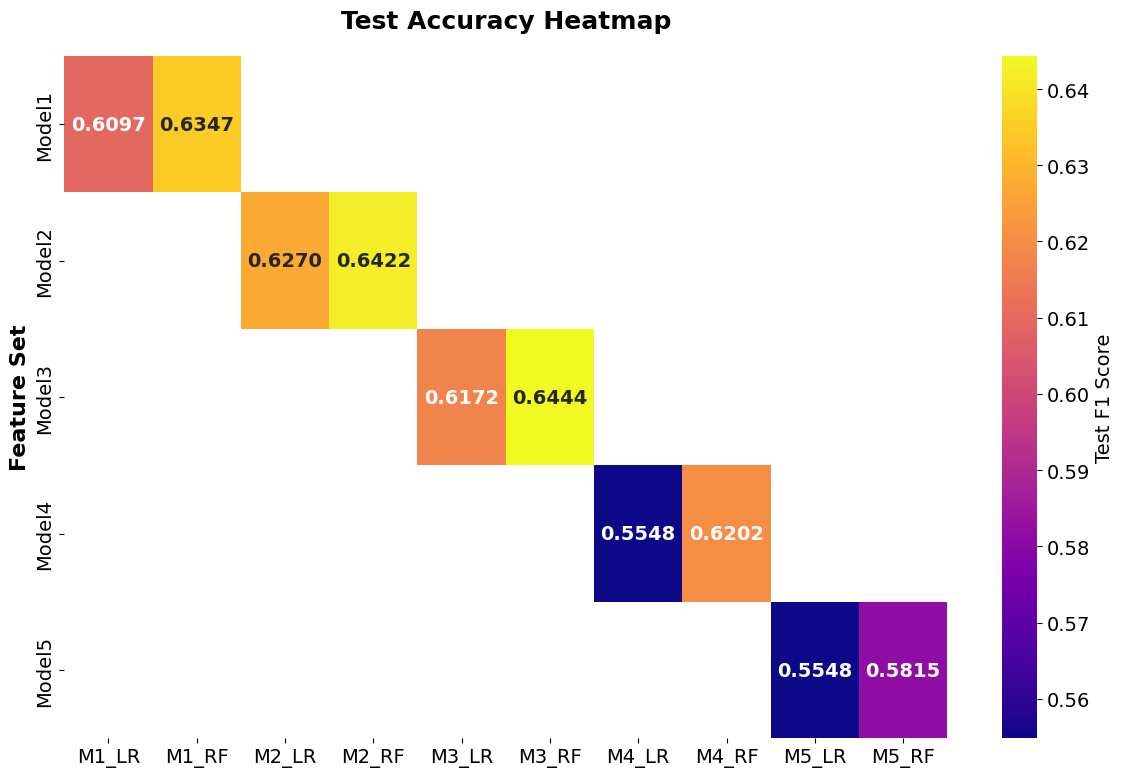


EXECUTIVE SUMMARY
Overall Best Model: M3_RF (Model3) - Accuracy: 0.6444

Detailed Accuracy Results:
Model         M1_LR   M1_RF  M2_LR   M2_RF   M3_LR   M3_RF   M4_LR   M4_RF  \
Feature_Set                                                                  
Model1       0.6097  0.6347    NaN     NaN     NaN     NaN     NaN     NaN   
Model2          NaN     NaN  0.627  0.6422     NaN     NaN     NaN     NaN   
Model3          NaN     NaN    NaN     NaN  0.6172  0.6444     NaN     NaN   
Model4          NaN     NaN    NaN     NaN     NaN     NaN  0.5548  0.6202   
Model5          NaN     NaN    NaN     NaN     NaN     NaN     NaN     NaN   

Model         M5_LR   M5_RF  
Feature_Set                  
Model1          NaN     NaN  
Model2          NaN     NaN  
Model3          NaN     NaN  
Model4          NaN     NaN  
Model5       0.5548  0.5815  


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set professional style
plt.rcParams['font.family'] = 'DejaVu Sans'  # Changed from Arial
plt.rcParams['font.size'] = 14  # Increased base font size
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False     # Remove top spine
plt.rcParams['axes.spines.right'] = False   # Remove right spine
sns.set_palette("Set2")

def plot_accuracy_metrics_slide(metrics_list, model_suffixes, save_path=None):
    """
    SLIDE 1: Model Performance Comparison
    Professional accuracy metrics visualization
    """
    
    # Combine data
    combined_data = []
    for metrics_df, suffix in zip(metrics_list, model_suffixes):
        temp_df = metrics_df.copy()
        temp_df['Feature_Set'] = suffix
        combined_data.append(temp_df)
    
    combined_df = pd.concat(combined_data, ignore_index=True)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 9))
    
    # Metrics to plot
    metrics = [
        ('Test_Accuracy', 'Accuracy', axes[0,0]),
        ('Test_AUC', 'AUC-ROC', axes[0,1]),
        ('Test_F1', 'F1-Score', axes[1,0]),
        ('Test_Precision', 'Precision', axes[1,1])
    ]
    
    for metric_col, metric_name, ax in metrics:
        # Create bar plot
        bars = sns.barplot(data=combined_df, x='Model', y=metric_col, hue='Feature_Set', ax=ax)
        
        # Customize appearance
        ax.set_title(f'{metric_name}', fontsize=18, fontweight='bold', pad=20)
        ax.set_xlabel('', fontsize=16, fontweight='bold')  # Removed 'Model Type'
        ax.set_ylabel(metric_name, fontsize=16, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Increase tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add value labels on bars
        for container in bars.containers:
            bars.bar_label(container, fmt='%.5f', fontsize=12, fontweight='bold')
        
        # Set consistent y-axis limits for better comparison
        y_min = max(0, combined_df[metric_col].min() - 0.05)
        y_max = min(1, combined_df[metric_col].max() + 0.05)
        ax.set_ylim(y_min, y_max)
        
        # Style legend - move to top right
        if metric_name == 'Accuracy':  # Only show legend once
            ax.legend(title='Feature Set', title_fontsize=14, fontsize=12, 
                     loc='upper right', frameon=True, fancybox=True, shadow=True)
        else:
            ax.get_legend().remove()
    
    plt.tight_layout()
    
    # Save with high DPI if path provided
    if save_path:
        plt.savefig(f'{save_path}_performance.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary table
    print("\n" + "="*80)
    print("PERFORMANCE SUMMARY TABLE")
    print("="*80)
    
    summary_cols = ['Test_Accuracy', 'Test_AUC', 'Test_F1', 'Test_Precision']
    for model in combined_df['Model'].unique():
        print(f"\n{model}:")
        model_data = combined_df[combined_df['Model'] == model][['Feature_Set'] + summary_cols]
        print(model_data.round(2).to_string(index=False))

def plot_feature_importance_slide(feature_importance_dict, model_suffixes, save_path=None):
    """
    SLIDE 2: Feature Importance Analysis
    Professional feature importance visualization
    """
    
    models = ['LogisticRegression', 'GradientBoosting', 'RandomForest']
    
    for model in models:
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle(f'{model} Feature Importance', 
                     fontsize=24, fontweight='bold', y=0.95)
        axes = axes.flatten()
        
        for i, suffix in enumerate(model_suffixes):
            ax = axes[i]
            
            if suffix in feature_importance_dict and model in feature_importance_dict[suffix]:
                importance_df = feature_importance_dict[suffix][model]
                top_features = importance_df.head(12)  # Show top 12 for better visibility
                
                # Create horizontal bar plot
                colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
                bars = ax.barh(range(len(top_features)), top_features['Importance'], 
                              color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
                
                # Customize appearance
                ax.set_yticks(range(len(top_features)))
                ax.set_yticklabels(top_features['Feature'], fontsize=13, fontweight='bold')
                ax.set_xlabel('Feature Importance', fontsize=16, fontweight='bold')
                ax.set_title(f'{suffix}', fontsize=18, fontweight='bold', pad=15)
                ax.invert_yaxis()
                ax.grid(True, alpha=0.3, axis='x')
                
                # Increase tick label sizes
                ax.tick_params(axis='both', which='major', labelsize=14)
                
                # Remove top and right spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                
                # Add value labels on bars
                for j, bar in enumerate(bars):
                    width = bar.get_width()
                    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                           f'{width:.2f}', ha='left', va='center', 
                           fontsize=12, fontweight='bold')
                
                # Removed ranking numbers as requested
                
            else:
                ax.text(0.5, 0.5, f'No data available\nfor {suffix}', 
                       transform=ax.transAxes, ha='center', va='center', 
                       fontsize=16, fontweight='bold', color='gray')
                ax.set_title(f'{suffix}', fontsize=18, fontweight='bold')
                # Remove spines for empty plots too
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        
        # Save with high DPI if path provided
        if save_path:
            plt.savefig(f'{save_path}_{model}_importance.png', dpi=300, bbox_inches='tight')
        
        plt.show()

def plot_model_comparison_slide(metrics_list, model_suffixes, save_path=None):
    """
    SLIDE 3: Test Accuracy Heatmap Only
    Professional heatmap visualization
    """
    
    # Combine data
    combined_data = []
    for metrics_df, suffix in zip(metrics_list, model_suffixes):
        temp_df = metrics_df.copy()
        temp_df['Feature_Set'] = suffix
        combined_data.append(temp_df)
    
    combined_df = pd.concat(combined_data, ignore_index=True)
    
    # Create figure with single plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Test Accuracy heatmap
    pivot_acc = combined_df.pivot(index='Feature_Set', columns='Model', values='Test_F1')
    
    # Use a colormap with better variation
    sns.heatmap(pivot_acc, annot=True, cmap='plasma', 
                fmt='.4f', ax=ax, cbar_kws={'label': 'Test F1 Score'},
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    
    ax.set_title('Test Accuracy Heatmap', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('', fontsize=16, fontweight='bold')  # Removed 'Model Type'
    ax.set_ylabel('Feature Set', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    plt.tight_layout()
    
    # Save with high DPI if path provided
    if save_path:
        plt.savefig(f'{save_path}_comparison.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print executive summary
    print("\n" + "="*80)
    print("EXECUTIVE SUMMARY")
    print("="*80)
    print(f"Overall Best Model: {combined_df.loc[combined_df['Test_F1'].idxmax(), 'Model']} "
          f"({combined_df.loc[combined_df['Test_F1'].idxmax(), 'Feature_Set']}) "
          f"- Accuracy: {combined_df['Test_F1'].max():.4f}")
    
    # Print detailed accuracy table
    print("\nDetailed Accuracy Results:")
    pivot_table = combined_df.pivot(index='Feature_Set', columns='Model', values='Test_F1')
    print(pivot_table.round(4))

# Usage for presentation:
# Create presentation-ready plots with high DPI export
metrics_list = [metrics1, metrics2, metrics3, metrics4, metrics5]
model_suffixes = ['Model1', 'Model2', 'Model3', 'Model4', 'Model5']
feature_importance_dict = {
    'Model1': importance1,
    'Model2': importance2, 
    'Model3': importance3,
    'Model4': importance4, 
    'Model5': importance5,
}

# SLIDE 1: Performance Metrics (saves as 'plots_performance.png')
plot_accuracy_metrics_slide(metrics_list, model_suffixes, save_path='plots')

# SLIDE 2: Feature Importance (saves as 'plots_RandomForest_importance.png', etc.)
#plot_feature_importance_slide(feature_importance_dict, model_suffixes, save_path='plots')

# SLIDE 3: Comprehensive Comparison (saves as 'plots_comparison.png')
plot_model_comparison_slide(metrics_list, model_suffixes, save_path='plots')